### PCA

**Метод главных компонент** - это широко используемая техника снижения размерности данных. Основная идея PCA заключается в ортогональном линейном преобразовании исходного пространства признаков в новое пространство меньшей размерности (главные компоненты), где первая компонента объясняет наибольшую дисперсию данных, вторая - следующую по величине и так далее.

## Используемые библиотеки

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

## Используемый датасет

In [18]:
data = load_wine()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
target_names = data.target_names

print(f"Размерность датасета: {df.shape}")
print("\nНазвания признаков:")
print(data.feature_names)
print("\nКлассы:")
print(target_names)

print("\nПервые 5 строк датасета:")
df.head()

Размерность датасета: (178, 14)

Названия признаков:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Классы:
['class_0' 'class_1' 'class_2']

Первые 5 строк датасета:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Обработка датасета

In [19]:
X = df.drop('target', axis=1)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Данные после стандартизации:")
print(np.round(X_scaled[:3, :5], 3))

Данные после стандартизации:
[[ 1.519 -0.562  0.232 -1.17   1.914]
 [ 0.246 -0.499 -0.828 -2.491  0.018]
 [ 0.197  0.021  1.109 -0.269  0.088]]


## Тепловая карта

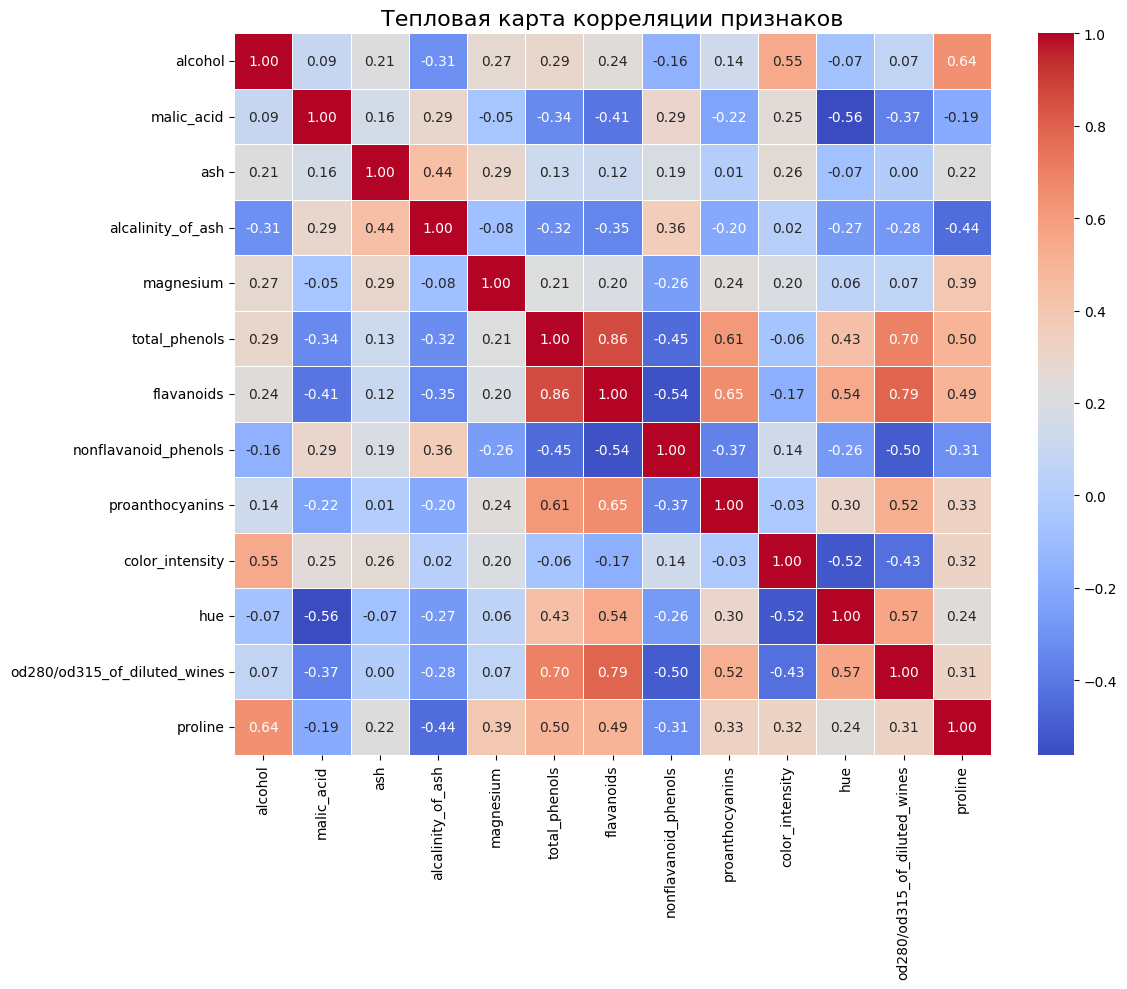

In [20]:
plt.figure(figsize=(12, 10))
corr_matrix = df.drop('target', axis=1).corr()
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5,
            fmt='.2f')
plt.title('Тепловая карта корреляции признаков', fontsize=16)
plt.tight_layout()
plt.show()

## Обучение модели

In [21]:
pca_full = PCA()
pca_full.fit(X_scaled)

pca_95 = PCA(n_components=0.95)
X_pca_95 = pca_95.fit_transform(X_scaled)
print(f"Для сохранения 95% дисперсии необходимо {pca_95.n_components_} компонент из {X.shape[1]} исходных.")

pca_2d = PCA(n_components=2)
principal_components = pca_2d.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
df_pca['target'] = y

print("\nКоэффициенты вклада признаков в первые 2 главные компоненты:")
print(pd.DataFrame(pca_2d.components_, columns=X.columns, index=['PC1', 'PC2']).round(3))

Для сохранения 95% дисперсии необходимо 10 компонент из 13 исходных.

Коэффициенты вклада признаков в первые 2 главные компоненты:
     alcohol  malic_acid    ash  alcalinity_of_ash  magnesium  total_phenols  \
PC1    0.144      -0.245 -0.002             -0.239      0.142          0.395   
PC2    0.484       0.225  0.316             -0.011      0.300          0.065   

     flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity  \
PC1       0.423                -0.299            0.313           -0.089   
PC2      -0.003                 0.029            0.039            0.530   

       hue  od280/od315_of_diluted_wines  proline  
PC1  0.297                         0.376    0.287  
PC2 -0.279                        -0.164    0.365  


## Прогнозы модели

In [22]:
print("Первые 5 строк данных после PCA преобразования:")
print(df_pca.head())


Первые 5 строк данных после PCA преобразования:
        PC1       PC2  target
0  3.316751  1.443463       0
1  2.209465 -0.333393       0
2  2.516740  1.031151       0
3  3.757066  2.756372       0
4  1.008908  0.869831       0


## Графики выходных результатов

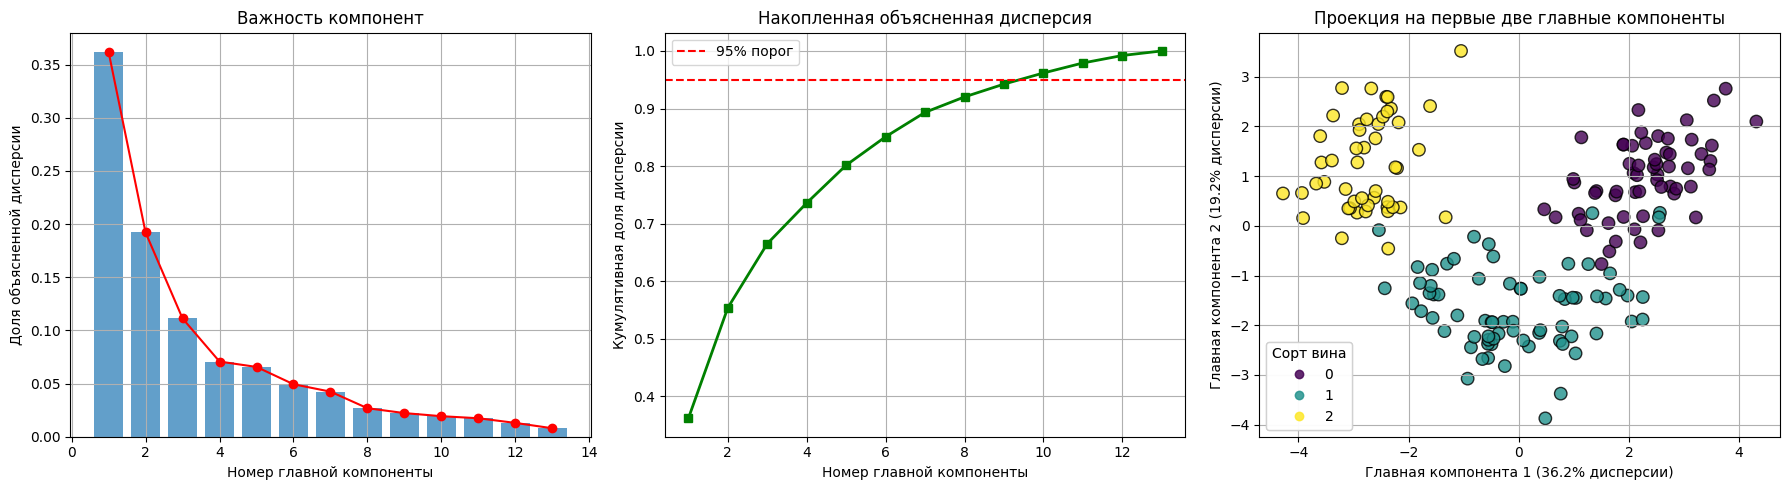

Точность модели KNN без PCA: 0.944


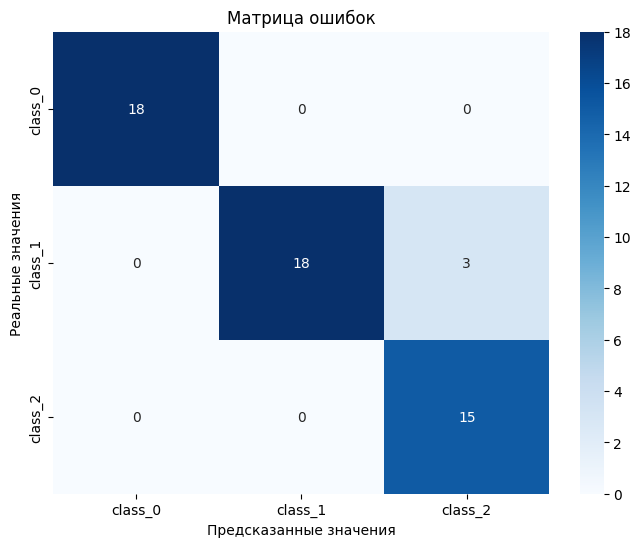

Точность модели KNN c PCA=2: 0.944


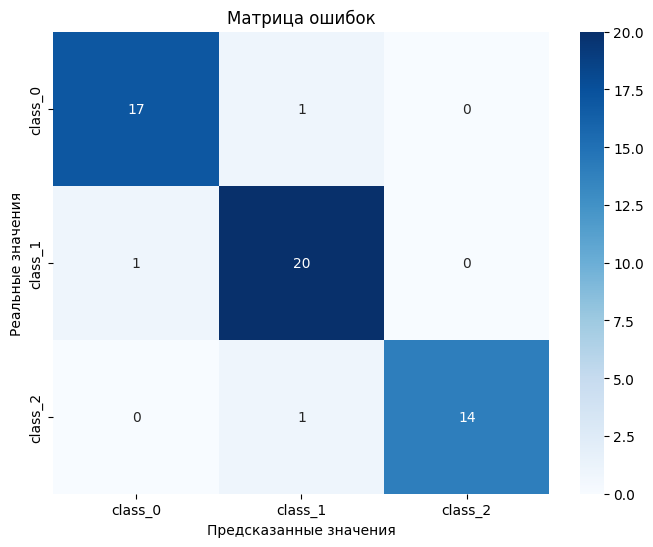

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

explained_variance = pca_full.explained_variance_ratio_
axes[0].bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.7)
axes[0].plot(range(1, len(explained_variance)+1), explained_variance, 'o-', color='red')
axes[0].set_xlabel('Номер главной компоненты')
axes[0].set_ylabel('Доля объясненной дисперсии')
axes[0].set_title('Важность компонент')
axes[0].grid(True)

cumulative_variance = np.cumsum(explained_variance)
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance, 's-', color='green', linewidth=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% порог')
axes[1].set_xlabel('Номер главной компоненты')
axes[1].set_ylabel('Кумулятивная доля дисперсии')
axes[1].set_title('Накопленная объясненная дисперсия')
axes[1].legend()
axes[1].grid(True)

scatter = axes[2].scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['target'],
                          cmap='viridis', edgecolor='k', s=80, alpha=0.8)
axes[2].set_xlabel(f'Главная компонента 1 ({explained_variance[0]:.1%} дисперсии)')
axes[2].set_ylabel(f'Главная компонента 2 ({explained_variance[1]:.1%} дисперсии)')
axes[2].set_title('Проекция на первые две главные компоненты')
legend1 = axes[2].legend(*scatter.legend_elements(), title="Сорт вина")
axes[2].add_artist(legend1)
axes[2].grid(True)

plt.tight_layout()
plt.show()


wine = load_wine()
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели KNN без PCA: {accuracy:.3f}")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            cmap='Blues',
            fmt='d',
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
plt.title(f'Матрица ошибок')
plt.ylabel('Реальные значения')
plt.xlabel('Предсказанные значения')
plt.show()

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)
y_pred_pca = knn_pca.predict(X_test_pca)

X_train_pca1 = pca.fit_transform(X_train_scaled)
X_test_pca1 = pca.transform(X_test_scaled)

knn_pca1 = KNeighborsClassifier(n_neighbors=5)
knn_pca1.fit(X_train_pca, y_train)
y_pred_pca1 = knn_pca.predict(X_test_pca)

print(f"Точность модели KNN c PCA=2: {accuracy:.3f}")
cm1 = confusion_matrix(y_test, y_pred_pca1)

plt.figure(figsize=(8, 6))
sns.heatmap(cm1,
            annot=True,
            cmap='Blues',
            fmt='d',
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
plt.title(f'Матрица ошибок')
plt.ylabel('Реальные значения')
plt.xlabel('Предсказанные значения')
plt.show()

accuracy = accuracy_score(y_test, y_pred_pca1)